# Trade Analysis
This notebook analyzes the results of the grid search experiment, focusing on the trade lists generated.
It covers:
1. Loading Trade Data
2. Calculating Key Performance Metrics
3. Visualizing Equity Curves
4. Analyzing Trade Distribution and Duration
5. Evaluating Drawdown Characteristics
6. Comparing Strategy Performance by Asset
7. Analyzing Win Rate vs. Risk-Reward Ratio

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Trade Data
Load trade CSV files. This section accepts a list of paths which can be:
- Local file paths (e.g., `../data/trades/trades_BTC.csv`)
- MLflow artifact URIs (e.g., `runs:/<run_id>/trades.csv`)

If the list is empty, it defaults to loading all CSV files from `../data/trades/`.

In [13]:
import mlflow
import urllib.parse
import re

# Set MLflow tracking URI to the database in the project root
# We assume the notebook is in 'examples/' and 'mlflow.db' is in the parent directory
db_path = os.path.abspath(os.path.join(os.getcwd(), "..", "mlflow.db"))
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")

# List of paths to trade files. 
# Can be local paths, MLflow artifact URIs (e.g., "runs:/<run_id>/trades.csv"), or file URIs
trade_sources = [
    # Example:
    # "runs:/00050a99d2924d078f8ee52bced48a34/trades_BTCUSDT_1h_rank1.csv",
    'file:///D:/py_projects/GammaNeutral/main/data/mlruns/6ed278fe535c41958baa964d968ba132/artifacts/trades/trades_Trix_Basic_Strategy_p30sig12_L.csv',
    'file:///D:/py_projects/GammaNeutral/main/data/mlruns/9ca016c70c35412d863168074a823f1e/artifacts/trades/trades_Trix_Basic_Strategy_p20sig12_L.csv',
    'file:///D:/py_projects/GammaNeutral/main/data/mlruns/28dd686f826045198ce7580ae9202687/artifacts/trades/trades_CCI_Basic_Strategy_p50_L.csv'
]

# If list is empty, default to globbing the local directory
if not trade_sources:
    trades_path = "../data/trades/"
    trade_sources = glob.glob(os.path.join(trades_path, "trades_*.csv"))

print(f"Processing {len(trade_sources)} trade sources.")

all_trades = []

for source in trade_sources:
    try:
        local_path = source
        run_id = None
        
        # Handle MLflow artifacts
        if source.startswith("runs:/"):
            # Extract run_id
            parts = source.split('/')
            if len(parts) > 1:
                run_id = parts[1]
            print(f"Downloading artifact: {source}")
            local_path = mlflow.artifacts.download_artifacts(artifact_uri=source) # pyright: ignore[reportPrivateImportUsage]
            
        elif source.startswith("mlflow-artifacts:"):
             # Handle mlflow-artifacts scheme if necessary
             pass

        # Handle file URIs (e.g. file:///D:/...)
        elif source.startswith("file:"):
            parsed_url = urllib.parse.urlparse(source)
            local_path = urllib.parse.unquote(parsed_url.path)
            # On Windows, urlparse path might start with /D:/..., we need to strip leading /
            if os.name == 'nt' and local_path.startswith('/') and ':' in local_path:
                local_path = local_path.lstrip('/')
            
        # Try to extract run_id from path if not already found
        if not run_id:
            # Look for 32-char hex string inside 'mlruns' folder structure
            match = re.search(r'mlruns[\\/]([a-f0-9]{32})[\\/]', local_path)
            if match:
                run_id = match.group(1)

        # Default metadata
        ticker = "Unknown"
        timeframe = "Unknown"
        strategy = "Unknown"
        strategy_type = "Unknown"
        indicators = "Unknown"
        params_dict = {}
        
        # 1. Try to get metadata from MLflow
        if run_id:
            try:
                run = mlflow.get_run(run_id)
                tags = run.data.tags
                params = run.data.params
                
                if 'ticker' in tags: ticker = tags['ticker']
                if 'timeframe' in tags: timeframe = tags['timeframe']
                
                # Extract strategy metadata
                # User requested strategy to be [ticker]_[run name]
                run_name = tags.get('mlflow.runName')
                if run_name:
                    strategy = f"{ticker}_{run_name}"
                elif 'strategy_name' in params: 
                    strategy = params['strategy_name']
                
                strategy_type = params.get('strategy_type', 'single')
                
                if strategy_type == 'single':
                    indicators = params.get('indicator', 'Unknown')
                elif strategy_type == 'combo':
                    n_indicators = int(params.get('n_indicators', 0))
                    inds = []
                    for i in range(1, n_indicators + 1):
                        ind_name = params.get(f'ind{i}_name')
                        if ind_name:
                            inds.append(ind_name)
                    indicators = "+".join(inds)
                
                params_dict = params
                
                print(f"Loaded metadata from MLflow run {run_id}: {ticker} {timeframe} {strategy} ({strategy_type})")
            except Exception as e:
                print(f"Could not fetch run {run_id} from MLflow: {e}")
        
        # Fallback: Try to extract metadata from filename if MLflow failed or run_id not found
        if ticker == "Unknown":
            filename = os.path.basename(local_path)
            filename_no_ext = os.path.splitext(filename)[0]
            parts = filename_no_ext.split('_')
            
            if filename.startswith("trades_"):
                strategy = filename_no_ext[7:]
            
            if len(parts) >= 4:
                ticker = parts[1]
                timeframe = parts[2]
                strategy = "_".join(parts[3:])
            
        df = pd.read_csv(local_path)
        df['ticker'] = ticker
        df['timeframe'] = timeframe
        df['strategy'] = strategy
        df['strategy_type'] = strategy_type
        df['indicators'] = indicators
        df['source_file'] = os.path.basename(local_path)
        
        # Add params as a column (repeated for all rows)
        df['params'] = [params_dict for _ in range(len(df))]
        
        # Convert time columns
        if 'entry_time' in df.columns:
            df['entry_time'] = pd.to_datetime(df['entry_time'])
        if 'exit_time' in df.columns:
            df['exit_time'] = pd.to_datetime(df['exit_time'])
        
        # Convert duration
        if 'duration' in df.columns:
            df['duration_dt'] = pd.to_timedelta(df['duration'])
            df['duration_hours'] = df['duration_dt'].dt.total_seconds() / 3600 # pyright: ignore[reportAttributeAccessIssue]
        
        all_trades.append(df)
        
    except Exception as e:
        print(f"Error loading {source}: {e}")

if all_trades:
    trades_df = pd.concat(all_trades, ignore_index=True)
    print(f"Loaded {len(trades_df)} trades.")
    display(trades_df.head())
else:
    print("No trades loaded.")

MLflow Tracking URI: sqlite:///d:\py_projects\GammaNeutral\main\mlflow.db
Processing 3 trade sources.
Loaded metadata from MLflow run 6ed278fe535c41958baa964d968ba132: ETHUSDT 1h ETHUSDT_Trix Basic Strategy_p30sig12_L (single)
Loaded metadata from MLflow run 9ca016c70c35412d863168074a823f1e: ETHUSDT 1h ETHUSDT_Trix Basic Strategy_p20sig12_L (single)
Loaded metadata from MLflow run 28dd686f826045198ce7580ae9202687: ETHUSDT 1h ETHUSDT_CCI Basic Strategy_p50_L (single)
Loaded 1301 trades.


,entry_time,exit_time,type,entry_price,exit_price,pnl_pct,duration,ticker,timeframe,strategy,strategy_type,indicators,source_file,params,duration_dt,duration_hours
0,2017-08-18 12:00:00,2017-08-18 16:00:00,long,307.78,298.80,-0.029177,0 days 04:00:00,ETHUSDT,1h,ETHUSDT_Trix Basic Strategy_p30sig12_L,single,trix,trades_Trix_Basic_Strategy_p30sig12_L.csv,"{'strategy_name': 'Trix Basic Strategy', 'stra...",0 days 04:00:00,4.0
1,2017-08-21 07:00:00,2017-09-02 13:00:00,long,320.28,354.16,0.105782,12 days 06:00:00,ETHUSDT,1h,ETHUSDT_Trix Basic Strategy_p30sig12_L,single,trix,trades_Trix_Basic_Strategy_p30sig12_L.csv,"{'strategy_name': 'Trix Basic Strategy', 'stra...",12 days 06:00:00,294.0
2,2017-09-06 23:00:00,2017-09-08 23:00:00,long,335.00,302.10,-0.098209,2 days 00:00:00,ETHUSDT,1h,ETHUSDT_Trix Basic Strategy_p30sig12_L,single,trix,trades_Trix_Basic_Strategy_p30sig12_L.csv,"{'strategy_name': 'Trix Basic Strategy', 'stra...",2 days 00:00:00,48.0
3,2017-09-12 07:00:00,2017-09-13 08:00:00,long,316.40,278.55,-0.119627,1 days 01:00:00,ETHUSDT,1h,ETHUSDT_Trix Basic Strategy_p30sig12_L,single,trix,trades_Trix_Basic_Strategy_p30sig12_L.csv,"{'strategy_name': 'Trix Basic Strategy', 'stra...",1 days 01:00:00,25.0
4,2017-09-17 23:00:00,2017-09-21 20:00:00,long,259.00,257.99,-0.003900,3 days 21:00:00,ETHUSDT,1h,ETHUSDT_Trix Basic Strategy_p30sig12_L,single,trix,trades_Trix_Basic_Strategy_p30sig12_L.csv,"{'strategy_name': 'Trix Basic Strategy', 'stra...",3 days 21:00:00,93.0


## 1.1 Detect Outliers
Identify statistical outliers in trade returns using the Interquartile Range (IQR) method.
Outliers are labeled in a new column `outlier` (True/False) to allow for easy filtering in subsequent analysis.

Outlier Detection (IQR=1.5):
  Total Trades: 1301
  Outliers: 116 (8.92%)

Top 5 Positive Outliers:


,ticker,strategy,entry_time,pnl_pct,outlier
1064,ETHUSDT,ETHUSDT_CCI Basic Strategy_p50_L,2017-08-19 07:00:00,1.114041,True
1067,ETHUSDT,ETHUSDT_CCI Basic Strategy_p50_L,2017-12-23 10:00:00,0.815354,True
710,ETHUSDT,ETHUSDT_Trix Basic Strategy_p20sig12_L,2021-04-25 21:00:00,0.798198,True
460,ETHUSDT,ETHUSDT_Trix Basic Strategy_p20sig12_L,2017-12-31 18:00:00,0.617986,True
147,ETHUSDT,ETHUSDT_Trix Basic Strategy_p30sig12_L,2020-07-19 07:00:00,0.595873,True



Top 5 Negative Outliers:


,ticker,strategy,entry_time,pnl_pct,outlier
1073,ETHUSDT,ETHUSDT_CCI Basic Strategy_p50_L,2018-02-03 14:00:00,-0.281449,True
391,ETHUSDT,ETHUSDT_Trix Basic Strategy_p30sig12_L,2025-03-02 21:00:00,-0.170766,True
453,ETHUSDT,ETHUSDT_Trix Basic Strategy_p20sig12_L,2017-11-29 13:00:00,-0.141427,True
135,ETHUSDT,ETHUSDT_Trix Basic Strategy_p30sig12_L,2020-05-07 22:00:00,-0.122804,True
778,ETHUSDT,ETHUSDT_Trix Basic Strategy_p20sig12_L,2022-02-23 10:00:00,-0.114787,True


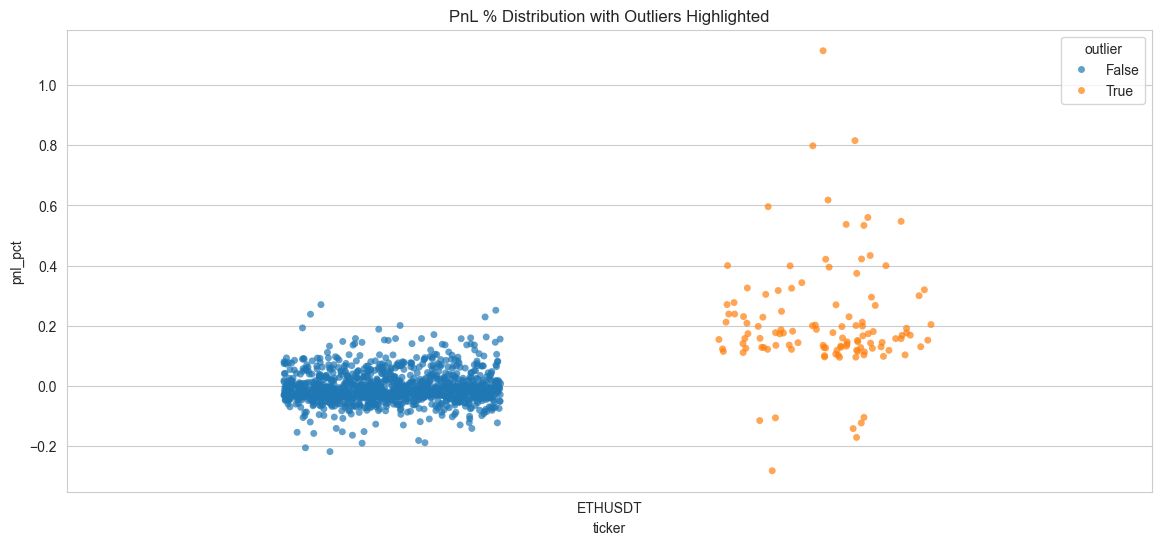

In [14]:
# 1.1 Detect Outliers
# We use the IQR method to label outliers in the 'pnl_pct' column.
# Outliers are calculated per strategy to account for different volatility profiles.

def is_outlier(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    return (series < lower_bound) | (series > upper_bound)

if not trades_df.empty:
    # Calculate outliers per (ticker, strategy) group
    # Using transform ensures the result aligns with the original DataFrame index
    trades_df['outlier'] = trades_df.groupby(['ticker', 'strategy'])['pnl_pct'].transform(is_outlier)
    
    n_outliers = trades_df['outlier'].sum()
    pct_outliers = n_outliers / len(trades_df)
    
    print(f"Outlier Detection (IQR=1.5):")
    print(f"  Total Trades: {len(trades_df)}")
    print(f"  Outliers: {n_outliers} ({pct_outliers:.2%})")
    
    if n_outliers > 0:
        print("\nTop 5 Positive Outliers:")
        display(trades_df[trades_df['outlier'] & (trades_df['pnl_pct'] > 0)]
                .sort_values('pnl_pct', ascending=False)[['ticker', 'strategy', 'entry_time', 'pnl_pct', 'outlier']].head())
        
        print("\nTop 5 Negative Outliers:")
        display(trades_df[trades_df['outlier'] & (trades_df['pnl_pct'] < 0)]
                .sort_values('pnl_pct', ascending=True)[['ticker', 'strategy', 'entry_time', 'pnl_pct', 'outlier']].head())
        
        # Visual check
        plt.figure(figsize=(14, 6))
        sns.stripplot(data=trades_df, x='ticker', y='pnl_pct', hue='outlier', dodge=True, alpha=0.7, jitter=0.2)
        plt.title('PnL % Distribution with Outliers Highlighted')
        plt.show()
else:
    print("No trades to analyze.")

### Alternative Outlier Detection Methods
Besides IQR, other common methods include:
1. **Z-Score**: Marks data points that are a certain number of standard deviations away from the mean (usually > 3). Assumes normal distribution.
2. **Modified Z-Score**: Uses Median and Median Absolute Deviation (MAD). More robust to extreme values than standard Z-Score.
3. **Isolation Forest**: An unsupervised learning algorithm useful for high-dimensional data or complex distributions.

In [15]:
# 1.2 Alternative: Modified Z-Score
# This method is often more robust for financial data which may not be normally distributed.

def is_outlier_mod_zscore(series, threshold=3.5):
    median = series.median()
    mad = (series - median).abs().median()
    
    if mad == 0:
        return pd.Series(False, index=series.index)
    
    mod_z_score = 0.6745 * (series - median) / mad
    return mod_z_score.abs() > threshold

if not trades_df.empty:
    trades_df['outlier_mod_z'] = trades_df.groupby(['ticker', 'strategy'])['pnl_pct'].transform(is_outlier_mod_zscore)
    
    n_outliers_z = trades_df['outlier_mod_z'].sum()
    print(f"Modified Z-Score Detection (Threshold=3.5):")
    print(f"  Outliers: {n_outliers_z} ({n_outliers_z/len(trades_df):.2%})")
    
    # Compare overlap
    overlap = (trades_df['outlier'] & trades_df['outlier_mod_z']).sum()
    print(f"  Overlap with IQR method: {overlap}")

Modified Z-Score Detection (Threshold=3.5):
  Outliers: 104 (7.99%)
  Overlap with IQR method: 104


## 2. Calculate Key Performance Metrics
Compute Win Rate, Profit Factor, Total Return, etc. for each strategy (Asset + Rank).

In [16]:
def calculate_metrics(group):
    total_trades = len(group)
    wins = group[group['pnl_pct'] > 0]
    losses = group[group['pnl_pct'] <= 0]
    
    win_rate = len(wins) / total_trades if total_trades > 0 else 0
    avg_win = wins['pnl_pct'].mean() if len(wins) > 0 else 0
    avg_loss = losses['pnl_pct'].mean() if len(losses) > 0 else 0
    
    total_return = group['pnl_pct'].sum()
    
    # Profit Factor
    gross_profit = wins['pnl_pct'].sum()
    gross_loss = abs(losses['pnl_pct'].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
    
    return pd.Series({
        'total_trades': total_trades,
        'win_rate': win_rate,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'total_return': total_return,
        'profit_factor': profit_factor
    })

# Group by strategy name instead of rank
metrics_by_strategy = trades_df.groupby(['ticker', 'timeframe', 'strategy']).apply(calculate_metrics).reset_index()
display(metrics_by_strategy.sort_values('total_return', ascending=False))

C:\Users\soyel\AppData\Local\Temp\ipykernel_2928\1617126126.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_by_strategy = trades_df.groupby(['ticker', 'timeframe', 'strategy']).apply(calculate_metrics).reset_index()


,ticker,timeframe,strategy,total_trades,win_rate,avg_win,avg_loss,total_return,profit_factor
1,ETHUSDT,1h,ETHUSDT_Trix Basic Strategy_p20sig12_L,632.0,0.375000,0.074203,-0.026637,7.064604,1.671448
2,ETHUSDT,1h,ETHUSDT_Trix Basic Strategy_p30sig12_L,432.0,0.365741,0.096334,-0.032315,6.366522,1.719033
0,ETHUSDT,1h,ETHUSDT_CCI Basic Strategy_p50_L,237.0,0.552743,0.097419,-0.075339,4.775884,1.598034


## 3. Visualize Equity Curves
Plot cumulative returns over time for the top ranked strategies.

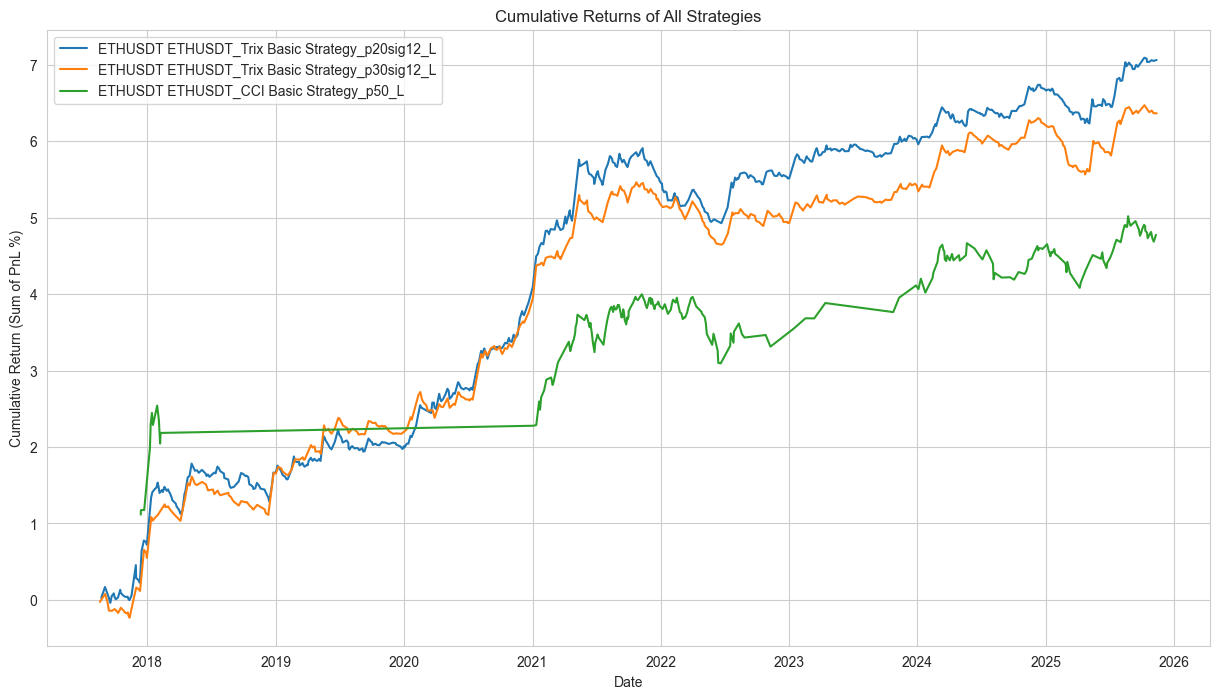

In [17]:
# Plot cumulative returns for ALL strategies
plt.figure(figsize=(15, 8))

# Sort by total return (descending)
top_strategies = metrics_by_strategy.sort_values('total_return', ascending=False)

if top_strategies.empty:
    print("No strategies found.")
else:
    for _, row in top_strategies.iterrows(): # pyright: ignore[reportGeneralTypeIssues]
        mask = (trades_df['ticker'] == row['ticker']) & \
               (trades_df['timeframe'] == row['timeframe']) & \
               (trades_df['strategy'] == row['strategy'])
        
        strategy_trades = trades_df[mask].sort_values('exit_time')
        strategy_trades['cumulative_return'] = strategy_trades['pnl_pct'].cumsum()
        
        # Create a label that describes the strategy
        label = f"{row['ticker']} {row['strategy']}"
        plt.plot(strategy_trades['exit_time'], strategy_trades['cumulative_return'], label=label)

    plt.title('Cumulative Returns of All Strategies')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return (Sum of PnL %)')
    plt.legend()
    plt.show()

## 4. Analyze Trade Distribution and Duration
Examine the distribution of PnL and how trade duration relates to profitability.

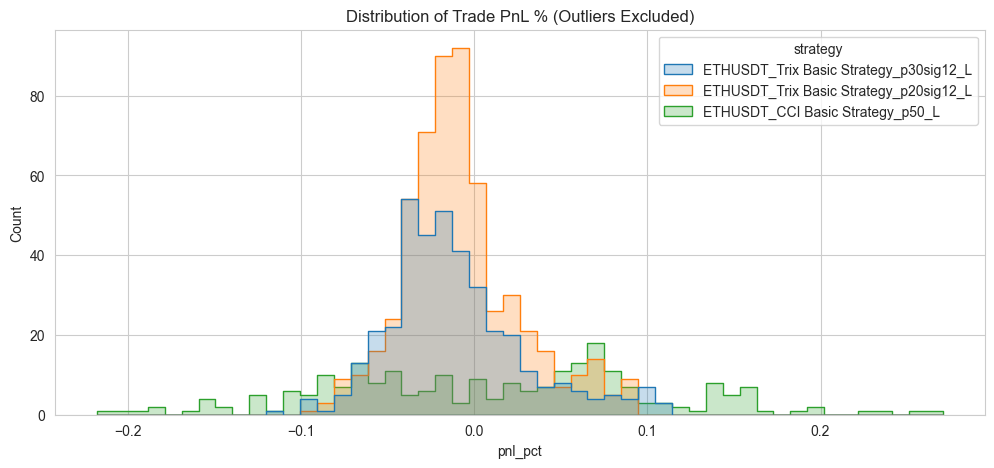

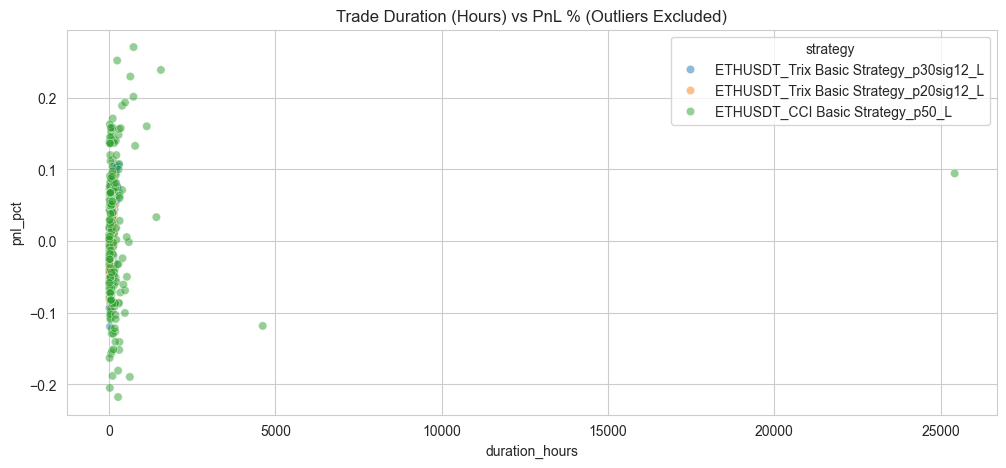

In [23]:
# Filter out outliers if the column exists
plot_data = trades_df[trades_df['outlier'] == False] if 'outlier' in trades_df.columns else trades_df

# PnL Distribution
plt.figure(figsize=(12, 5))
sns.histplot(data=plot_data, x='pnl_pct', hue='strategy', element="step", bins=50)
plt.title('Distribution of Trade PnL % (Outliers Excluded)')
plt.show()

# Duration vs PnL
plt.figure(figsize=(12, 5))
sns.scatterplot(data=plot_data, x='duration_hours', y='pnl_pct', hue='strategy', alpha=0.5)
plt.title('Trade Duration (Hours) vs PnL % (Outliers Excluded)')
plt.show()

## 5. Evaluate Drawdown Characteristics
Visualize the drawdown periods for the strategies.

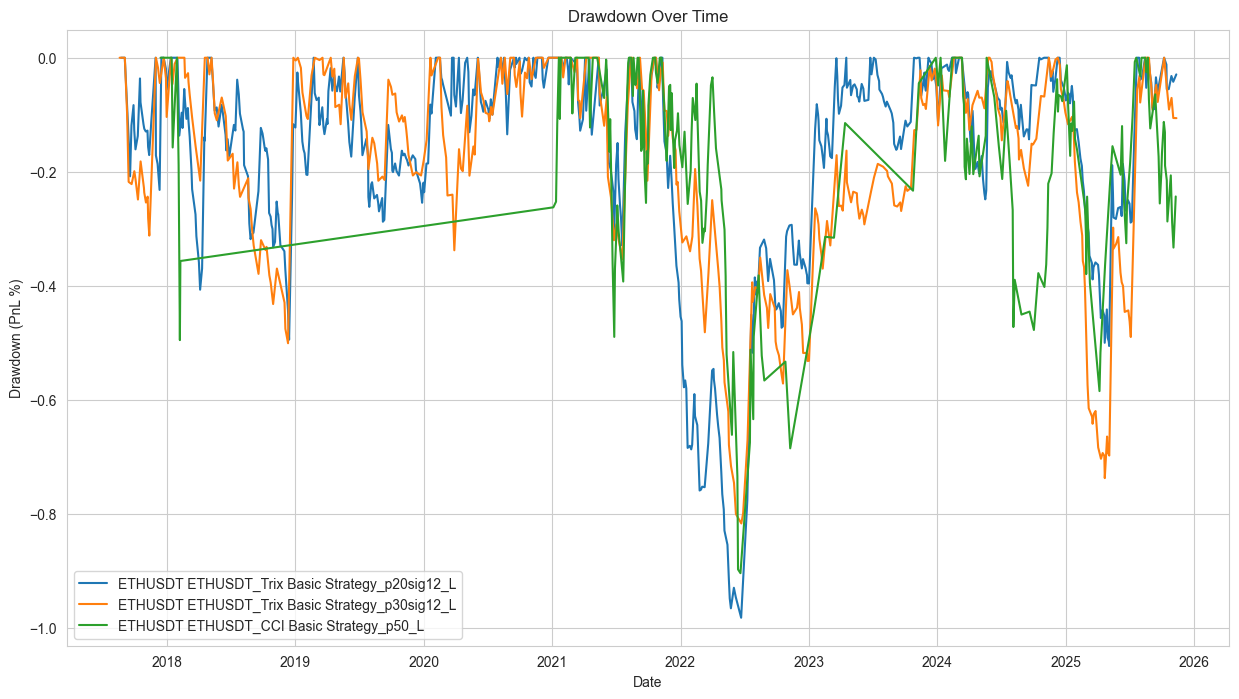

In [24]:
def calculate_drawdown(pnl_series):
    cum_ret = pnl_series.cumsum()
    running_max = cum_ret.cummax()
    drawdown = cum_ret - running_max
    return drawdown

plt.figure(figsize=(15, 8))

for _, row in top_strategies.iterrows(): # pyright: ignore[reportGeneralTypeIssues]
    mask = (trades_df['ticker'] == row['ticker']) & \
           (trades_df['timeframe'] == row['timeframe']) & \
           (trades_df['strategy'] == row['strategy'])
    
    strategy_trades = trades_df[mask].sort_values('exit_time')
    drawdown = calculate_drawdown(strategy_trades['pnl_pct'])
    
    label = f"{row['ticker']} {row['strategy']}"
    plt.plot(strategy_trades['exit_time'], drawdown, label=label)

plt.title('Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown (PnL %)')
plt.legend()
plt.show()

## 6. Compare Strategy Performance by Asset
Compare Win Rate and Total Return across different assets.

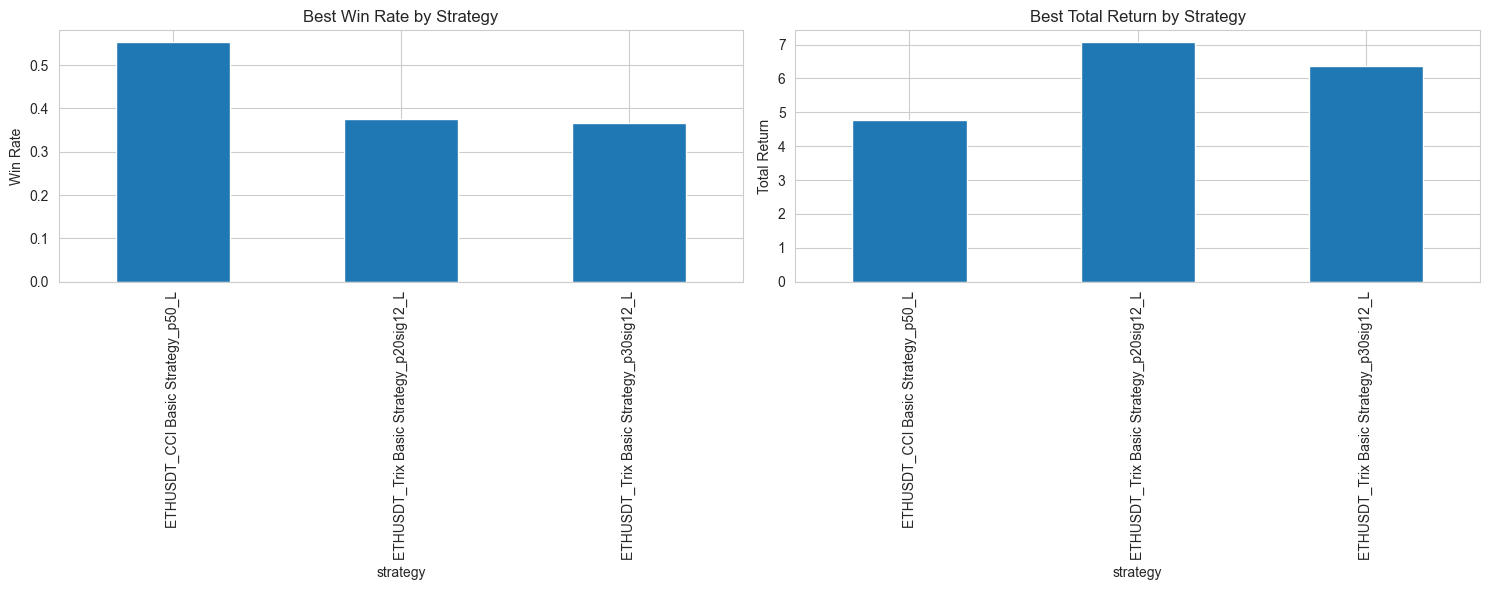

In [25]:
# Compare metrics by asset
# Instead of filtering by 'rank1', we take the best performing strategy for each ticker
asset_metrics = metrics_by_strategy.sort_values('total_return', ascending=False).groupby('strategy').first()

if asset_metrics.empty:
    print("No asset metrics to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    asset_metrics['win_rate'].plot(kind='bar', ax=axes[0], title='Best Win Rate by Strategy')
    axes[0].set_ylabel('Win Rate')

    asset_metrics['total_return'].plot(kind='bar', ax=axes[1], title='Best Total Return by Strategy')
    axes[1].set_ylabel('Total Return')

    plt.tight_layout()
    plt.show()

## 7. Analyze Win Rate vs. Risk-Reward Ratio
Scatter plot to categorize strategies based on their Win Rate and Risk/Reward profile.

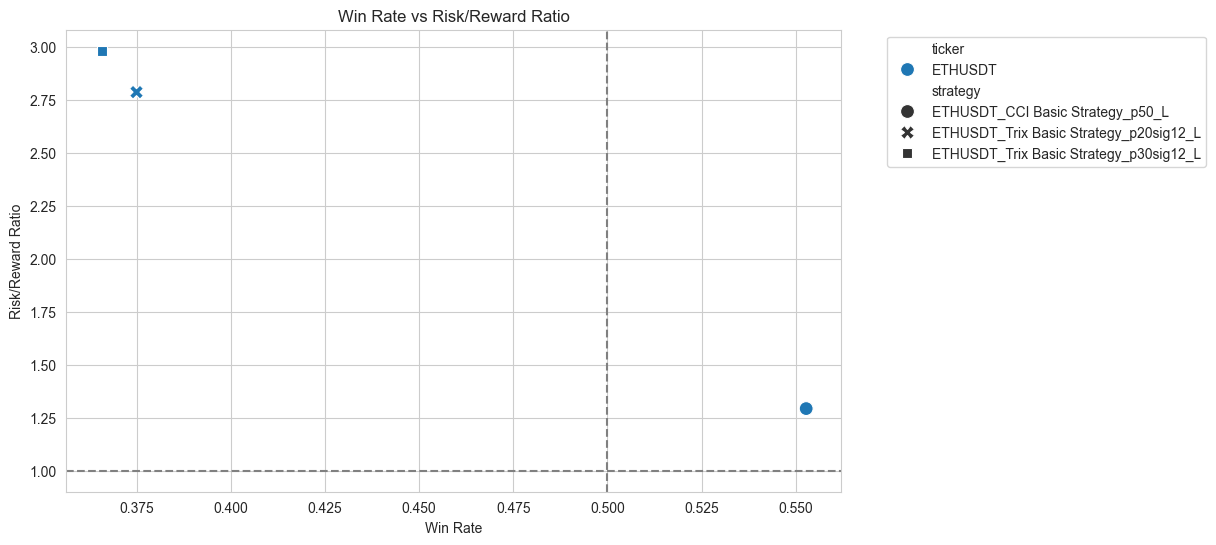

In [26]:
metrics_by_strategy['risk_reward'] = abs(metrics_by_strategy['avg_win'] / metrics_by_strategy['avg_loss'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=metrics_by_strategy, x='win_rate', y='risk_reward', hue='ticker', style='strategy', s=100)

# Add reference lines
plt.axvline(0.5, color='gray', linestyle='--')
plt.axhline(1.0, color='gray', linestyle='--')

plt.title('Win Rate vs Risk/Reward Ratio')
plt.xlabel('Win Rate')
plt.ylabel('Risk/Reward Ratio')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 8. Analysis of Losing Trades
Identify patterns in losing trades to refine the strategy.
- **Worst Trades**: Inspect the largest individual losses.
- **Seasonality**: Check if losses cluster around specific hours or days.
- **Duration**: See if losing trades tend to be shorter or longer than average.

Winning Trades: 417 | Avg Win: 4.84%
Losing Trades: 768 | Avg Loss: -3.43%


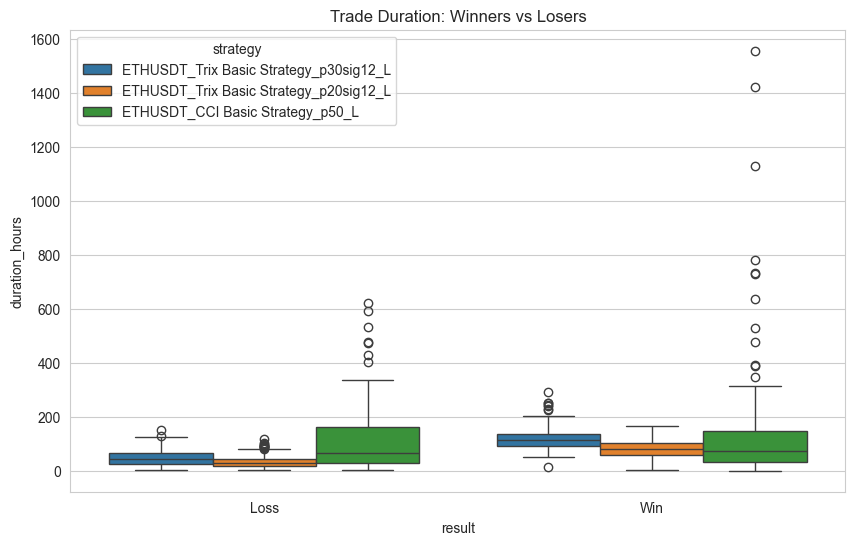

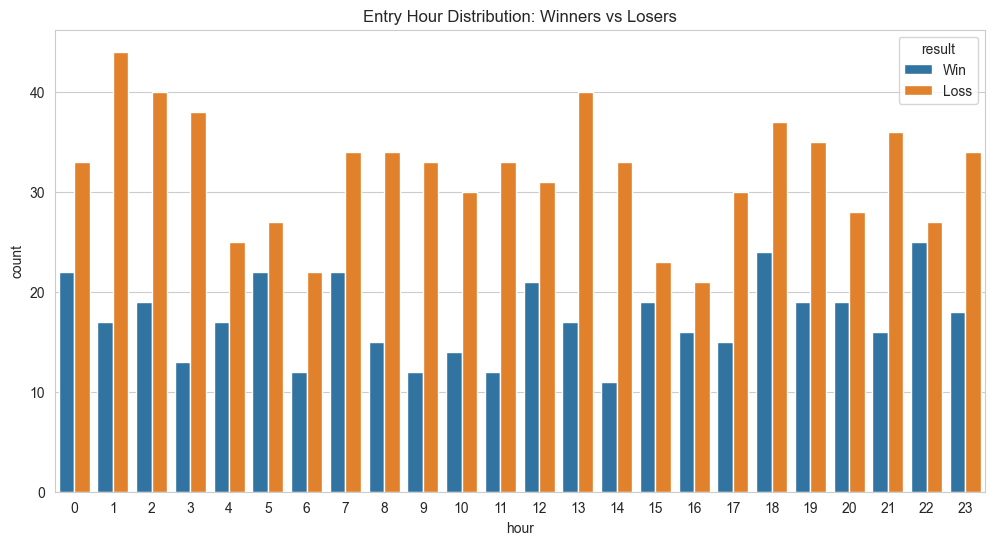

Recalculating indicators for analysis...
📂 Cargando datos guardados de ETHUSDT...
  ✓ 1h: 72107 velas (2017-08-17 04:00:00 a 2025-11-12 22:00:00)
✓ Datos cargados exitosamente desde D:\py_projects\GammaNeutral\main\data\market/
Processed ETHUSDT ETHUSDT_CCI Basic Strategy_p50_L: Added ['Open', 'High', 'Low', 'Close', 'Volume', 'candle_rtn', 'future_ret+1', 'cci']
📂 Cargando datos guardados de ETHUSDT...
  ✓ 1h: 72107 velas (2017-08-17 04:00:00 a 2025-11-12 22:00:00)
✓ Datos cargados exitosamente desde D:\py_projects\GammaNeutral\main\data\market/
Processed ETHUSDT ETHUSDT_Trix Basic Strategy_p20sig12_L: Added ['Open', 'High', 'Low', 'Close', 'Volume', 'candle_rtn', 'future_ret+1', 'trix']
📂 Cargando datos guardados de ETHUSDT...
  ✓ 1h: 72107 velas (2017-08-17 04:00:00 a 2025-11-12 22:00:00)
✓ Datos cargados exitosamente desde D:\py_projects\GammaNeutral\main\data\market/
Processed ETHUSDT ETHUSDT_Trix Basic Strategy_p30sig12_L: Added ['Open', 'High', 'Low', 'Close', 'Volume', 'candle_

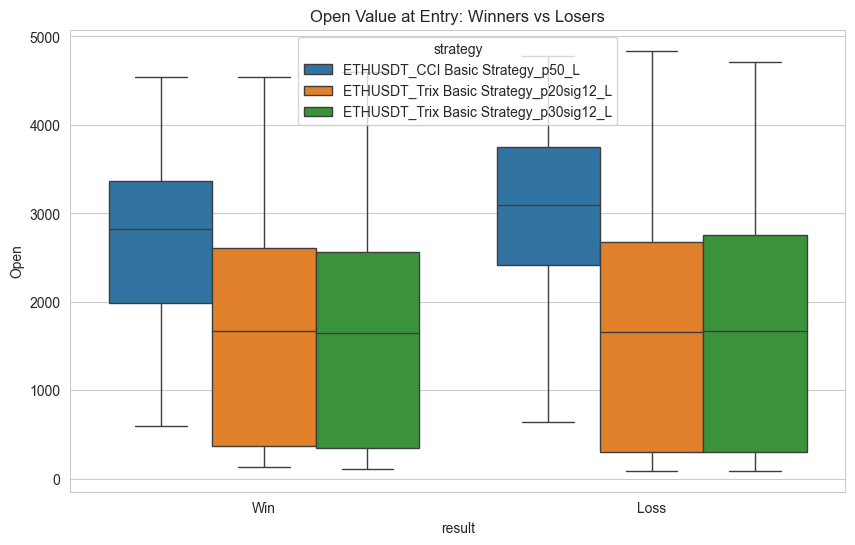

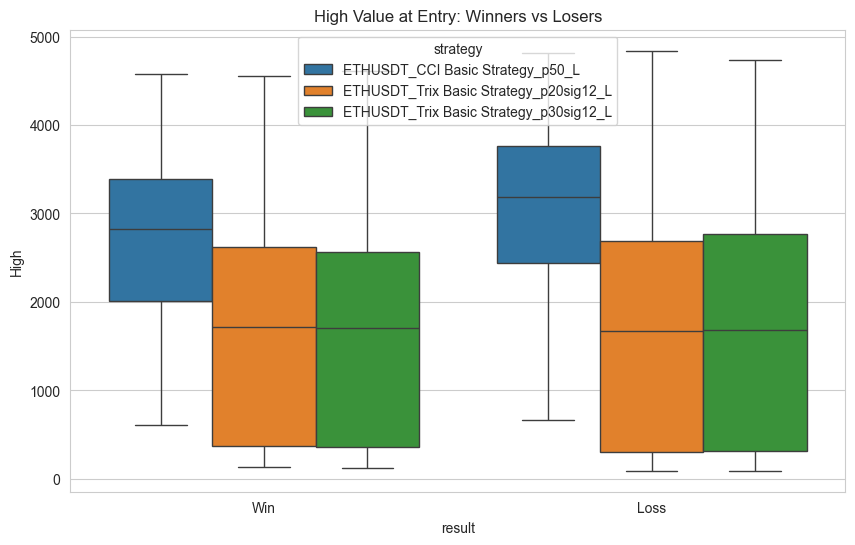

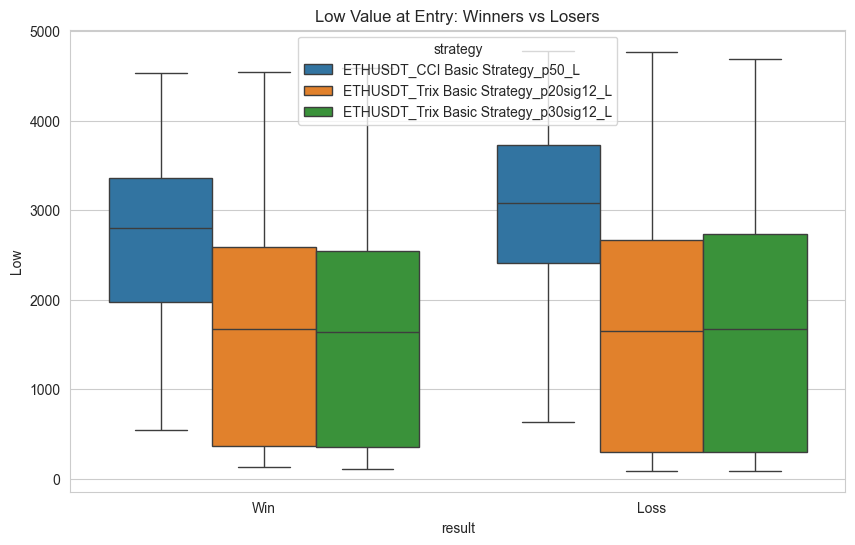

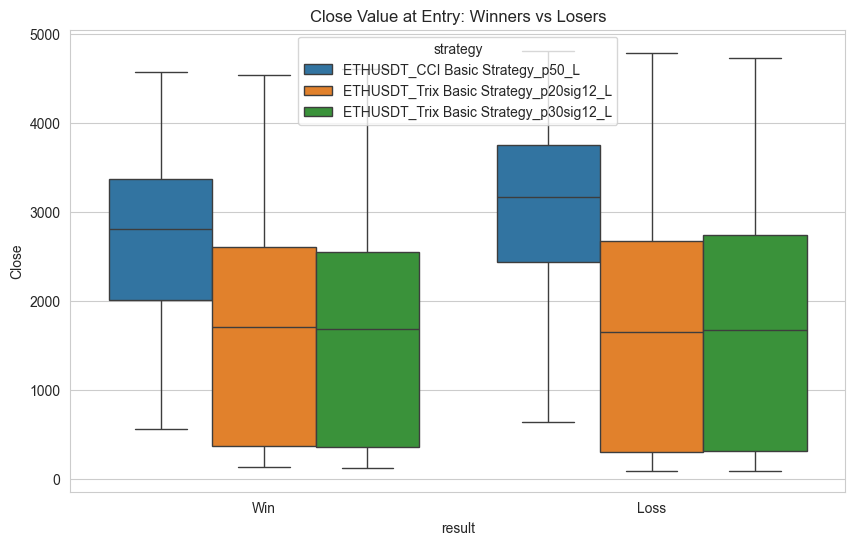

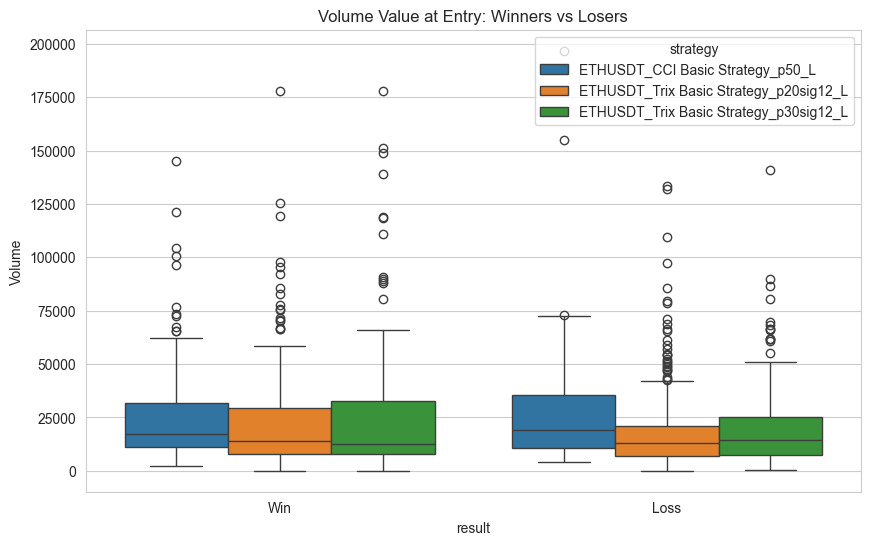

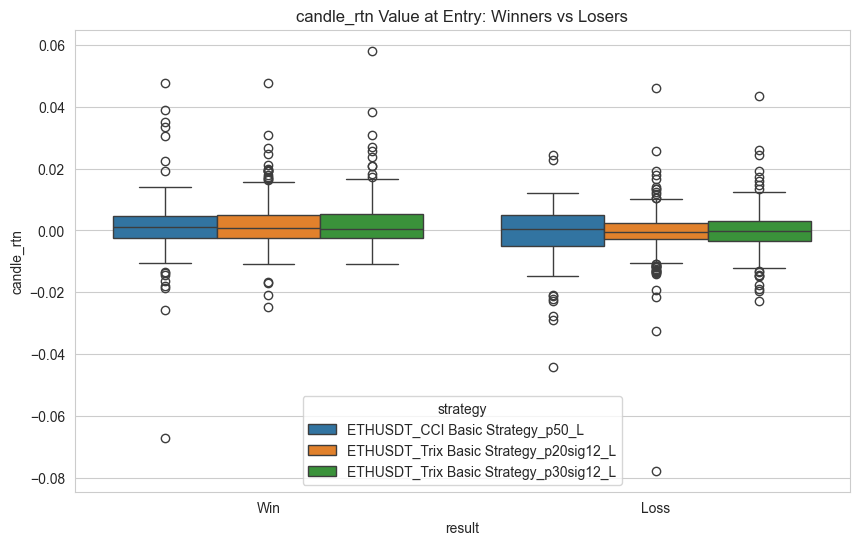

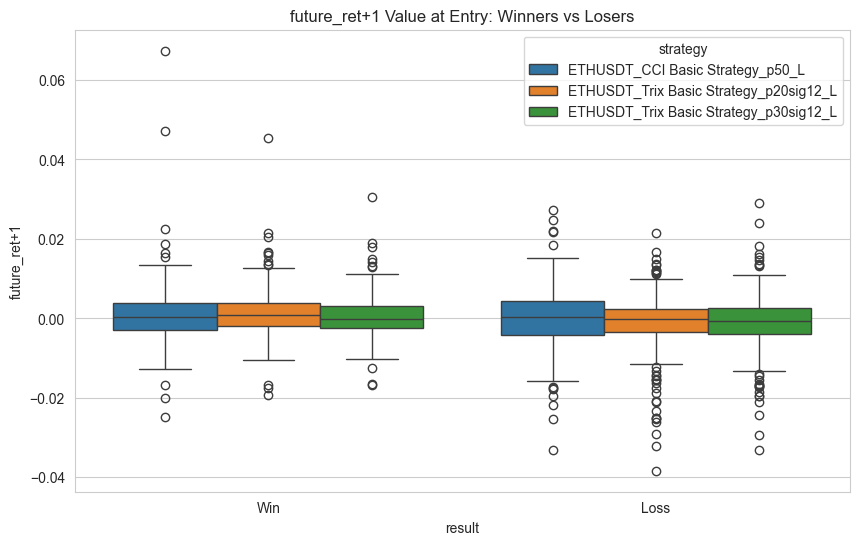

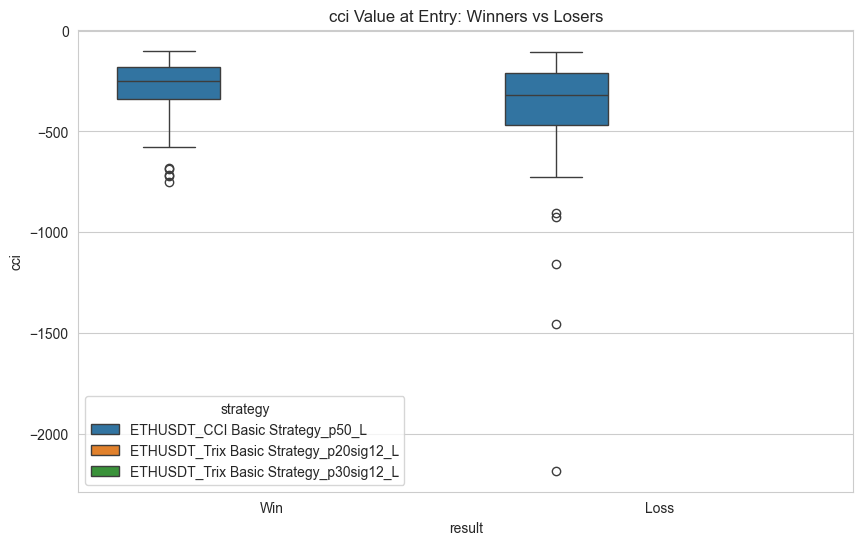

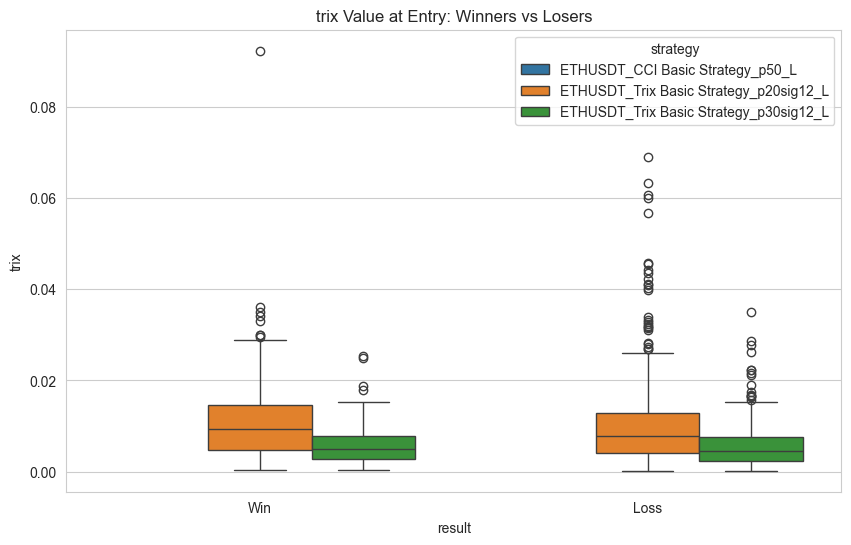

In [30]:
# 8. Winning vs Losing Trade Analysis with Indicator Values

import sys
from pathlib import Path

# Add project root to path to import src modules
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.trading_strategy.data_loader import load_saved_data
from src.trading_strategy.indicators import calculate_indicator_and_signals, calculate_returns_and_momentum

trades_df_NoOutliers = trades_df[trades_df['outlier'] == False] if 'outlier' in trades_df.columns else trades_df

# Separate winners and losers
winning_trades = trades_df_NoOutliers[trades_df_NoOutliers['pnl_pct'] > 0].copy()
losing_trades = trades_df_NoOutliers[trades_df_NoOutliers['pnl_pct'] <= 0].copy()
print(f"Winning Trades: {len(winning_trades)} | Avg Win: {winning_trades['pnl_pct'].mean():.2%}")
print(f"Losing Trades: {len(losing_trades)} | Avg Loss: {losing_trades['pnl_pct'].mean():.2%}")

# --- 1. Duration Analysis ---
trades_df_NoOutliers['result'] = np.where(trades_df_NoOutliers['pnl_pct'] > 0, 'Win', 'Loss')
plt.figure(figsize=(10, 6))
sns.boxplot(data=trades_df_NoOutliers[trades_df_NoOutliers['duration_hours'] < trades_df_NoOutliers['duration_hours'].std()*3], x='result', y='duration_hours', hue='strategy')
plt.title('Trade Duration: Winners vs Losers')
plt.show()

# --- 2. Time Analysis (Hour of Day) ---
trades_df_NoOutliers['hour'] = trades_df_NoOutliers['entry_time'].dt.hour
plt.figure(figsize=(12, 6))
sns.countplot(data=trades_df_NoOutliers, x='hour', hue='result')
plt.title('Entry Hour Distribution: Winners vs Losers')
plt.show()

# --- 3. Indicator Value Analysis ---
# Recalculate indicators using metadata from MLflow (stored in trades_df)

# We will process each unique (ticker, timeframe, strategy) combination
# Include metadata columns. Note: 'params' is a dict (unhashable), so we can't use drop_duplicates on it directly.
unique_combos = trades_df_NoOutliers.groupby(['ticker', 'timeframe', 'strategy', 'strategy_type', 'indicators'])['params'].first().reset_index()

trades_with_indicators = []

print("Recalculating indicators for analysis...")

for _, row in unique_combos.iterrows(): # pyright: ignore[reportGeneralTypeIssues]
    ticker = row['ticker']
    timeframe = row['timeframe']
    strategy_name = row['strategy']
    strategy_type = row['strategy_type']
    indicators_str = row['indicators']
    params_raw = row['params']
    
    # 1. Load Market Data
    try:
        data = load_saved_data(ticker=ticker, timeframes=[timeframe])
        if not data or timeframe not in data:
            print(f"Skipping {ticker} {timeframe}: No market data found.")
            continue
        
        df_market = data[timeframe]
        # Ensure returns are calculated (needed for some indicators)
        df_market = calculate_returns_and_momentum(
            df_market,
            compute_indicators=False)
        
        # 2. Determine Indicators to Calculate
        indicators_to_calc = []
        
        if strategy_type == 'single':
            # Single strategy: indicators_str is the indicator name
            # params_raw contains the parameters directly
            
            # Convert params to correct types (int/float)
            clean_params = {}
            for k, v in params_raw.items():
                # Skip metadata keys
                if k in ['strategy_name', 'strategy_type', 'indicator', 'position_type', 'train_split', 'git_commit']:
                    continue
                try:
                    # Try to convert to number
                    if isinstance(v, str):
                        if '.' in v: clean_params[k] = float(v)
                        else: clean_params[k] = int(v)
                    else:
                        clean_params[k] = v
                except:
                    clean_params[k] = v
            
            indicators_to_calc.append((indicators_str, clean_params))
            
        elif strategy_type == 'combo':
            # Combo strategy: extract from ind{i}_* params
            # We look for ind1_name, ind2_name, etc.
            i = 1
            while True:
                ind_key = f"ind{i}_name"
                if ind_key not in params_raw:
                    break
                
                ind_name = params_raw[ind_key]
                ind_params = {}
                prefix = f"ind{i}_"
                
                for k, v in params_raw.items():
                    if k.startswith(prefix) and k != ind_key:
                        param_name = k[len(prefix):] # strip prefix
                        try:
                            if isinstance(v, str):
                                if '.' in v: ind_params[param_name] = float(v)
                                else: ind_params[param_name] = int(v)
                            else:
                                ind_params[param_name] = v
                        except:
                            ind_params[param_name] = v
                
                indicators_to_calc.append((ind_name, ind_params))
                i += 1
        
        if not indicators_to_calc:
            print(f"Skipping {strategy_name}: No indicators found in metadata.")
            continue

        # 3. Calculate Indicators
        for ind_name, ind_params in indicators_to_calc:
            try:
                # This adds columns to df_market (e.g., 'trix', 'trix_signal')
                df_market = calculate_indicator_and_signals(df_market, ind_name, ind_params, inplace=False)
                
                # Rename generic 'indicator_value' to specific indicator name if present
                if 'indicator_value' in df_market.columns:
                    df_market = df_market.rename(columns={'indicator_value': ind_name})
                    
            except Exception as e:
                print(f"  Error calculating {ind_name} for {strategy_name}: {e}")
        
        # 4. Merge with Trades
        # Filter trades for this specific combo
        mask = (trades_df['ticker'] == ticker) & \
               (trades_df['timeframe'] == timeframe) & \
               (trades_df['strategy'] == strategy_name)
        
        subset_trades = trades_df[mask].copy()
        
        # We need to join on entry_time. 
        # Market data index is timestamp.
        
        # Get list of indicator columns (those added to df_market)
        # We know standard cols, so new ones are indicators
        standard_market_cols = ['open', 'high', 'low', 'close', 'volume', 'returns', 'log_returns', 'volatility', 'momentum']
        indicator_cols = [c for c in df_market.columns if c not in standard_market_cols and c != 'signal']
        
        # Create a lookup df
        lookup_df = df_market[indicator_cols]
        
        # Merge
        subset_trades = subset_trades.merge(lookup_df, left_on='entry_time', right_index=True, how='left')
        
        trades_with_indicators.append(subset_trades)
        print(f"Processed {ticker} {strategy_name}: Added {indicator_cols}")
        
    except Exception as e:
        print(f"Error processing {ticker} {strategy_name}: {e}")

if trades_with_indicators:
    full_trades_df = pd.concat(trades_with_indicators, ignore_index=True)
    full_trades_df_NoOutliers = full_trades_df[full_trades_df['outlier'] == False] if 'outlier' in full_trades_df.columns else full_trades_df
    
    # Now plot indicator values for Winners vs Losers
    # Identify numeric columns that are not standard trade cols
    std_cols = set(trades_df_NoOutliers.columns)
    new_cols = [c for c in full_trades_df_NoOutliers.columns if c not in std_cols and pd.api.types.is_numeric_dtype(full_trades_df_NoOutliers[c])]
    
    if new_cols:
        print(f"\nAnalyzing Indicator Values: {new_cols}")
        for col in new_cols:
            plt.figure(figsize=(10, 6))
            sns.boxplot(data=full_trades_df_NoOutliers, x='result', y=col, hue='strategy')
            plt.title(f'{col} Value at Entry: Winners vs Losers')
            plt.show()
    else:
        print("No indicator columns were successfully added.")
else:
    print("Could not recalculate indicators for any strategy.")